# Inverse PINN for 1D linear elastostatics with batching

The goal is to identify both the displacement $u(x)$ and the unknown constant Young's modulus $E>0$ of a one-dimensional elastic bar on

$$
\Omega=(0,1).
$$

For a synthetic inverse experiment, the exact displacement is

$$
u_{\mathrm{exact}}(x)=a\sin(2\pi x),\qquad 0<a<\frac{1}{2\pi}.
$$

The strain and stress are

$$
\varepsilon(x)=u'(x),\qquad \sigma(x)=E u'(x),
$$

and equilibrium requires

$$
\left(Eu''(x)\right)+b(x)=0.
$$

A hidden value $E_{\mathrm{true}}$ is used only once to generate the fixed known body force

$$
b_{\mathrm{known}}(x)=4\pi^2E_{\mathrm{true}}a\sin(2\pi x).
$$

The PINN learns its own value $E_\theta$ directly from the PDE and sparse displacement observations.


## 1. Library imports


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float64)


## 2. Parameters

Set `USE_NOISY_DATA = False` to use exact sparse observations. Set it to `True` to add independent zero-mean Gaussian measurement noise:

$$
u_i^{\mathrm{obs}}=u_{\mathrm{exact}}(x_i)+\eta_i,\qquad \eta_i\sim\mathcal N(0,s_{\mathrm{noise}}^2).
$$


In [44]:
USE_NOISY_DATA = True
NOISE_RELATIVE_STD = 0.02

L = 1.0
E_TRUE = 1.0
E_INITIAL = 5.0
AMPLITUDE = 0.05

N_PDE_TRAIN = 1000
N_PDE_TEST = 1000
PDE_BATCH_SIZE = 16
N_DATA_TOTAL = 20
TRAIN_FRACTION = 0.80
N_DATA_TRAIN = int(TRAIN_FRACTION * N_DATA_TOTAL)
N_DATA_TEST = N_DATA_TOTAL - N_DATA_TRAIN

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

WEIGHT_PDE = 1.0
WEIGHT_DATA = 1000.0

NOISE_STD = NOISE_RELATIVE_STD * AMPLITUDE

torch.manual_seed(SEED)



## 3. Exact solution and fixed known loading

In [45]:
def exact_solution(x):
    """Exact displacement used to generate synthetic observations."""
    return AMPLITUDE * torch.sin(2.0 * torch.pi * x)


def exact_strain(x):
    """Exact strain u'(x)."""
    return 2.0 * torch.pi * AMPLITUDE * torch.cos(2.0 * torch.pi * x)


def exact_stress(x):
    """Exact stress generated with the hidden true modulus."""
    return E_TRUE * exact_strain(x)


def known_body_force(x):
    """Fixed known body force."""
    return (4.0 * torch.pi**2 * E_TRUE * AMPLITUDE * torch.sin(2.0 * torch.pi * x))


## 4. Neural network and directly trainable Young's modulus

The network predicts $u_\theta(x)$. Young's modulus itself is stored directly as an `nn.Parameter`:

$$
E_\theta=\texttt{model.E}.
$$

No positivity transformation, clipping, or additional constraint is applied to $E_\theta$. The experiment therefore shows whether unconstrained optimization keeps the identified modulus physically admissible.


In [46]:
class InversePINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 5),
            nn.Tanh(),
            nn.Linear(5, 5),
            nn.Tanh(),
            nn.Linear(5, 5),
            nn.Tanh(),
            nn.Linear(5, 1),
        )

        self.E = nn.Parameter(torch.tensor(E_INITIAL))

    def forward(self, x):
        return self.net(x)

    def young_modulus(self):
        return self.E


model = InversePINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Collocation points and PDE batching

Training collocation points are sampled uniformly from $(0,1)$. Only these PDE points are divided into mini-batches. `shuffle=True` creates a new random ordering in every Adam epoch. Sparse observations are always used as a complete set. L-BFGS uses all collocation points simultaneously.


In [47]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
x_pde_train = L * torch.rand(N_PDE_TRAIN, 1, generator=pde_train_generator)

pde_dataset = TensorDataset(x_pde_train)
pde_batch_generator = torch.Generator().manual_seed(SEED + 2)
pde_loader = DataLoader(pde_dataset, batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator)

pde_test_generator = torch.Generator().manual_seed(SEED + 3)
x_pde_test = L * torch.rand(N_PDE_TEST, 1, generator=pde_test_generator)
x_pde_test, _ = torch.sort(x_pde_test, dim=0)


## 6. Train/test split of sparse observations

All sparse sensor locations are sampled in the interior of the bar and randomly split into training and test subsets.


In [48]:
data_location_generator = torch.Generator().manual_seed(SEED + 4)
x_data_all = L * torch.rand(N_DATA_TOTAL, 1, generator=data_location_generator)

split_generator = torch.Generator().manual_seed(SEED + 5)
permutation = torch.randperm(N_DATA_TOTAL, generator=split_generator)
train_indices = permutation[:N_DATA_TRAIN]
test_indices = permutation[N_DATA_TRAIN:]

u_data_all_clean = exact_solution(x_data_all).detach()
u_data_all_observed = u_data_all_clean.clone()

if USE_NOISY_DATA:
    noise_generator = torch.Generator().manual_seed(SEED + 6)
    u_data_all_observed += NOISE_STD * torch.randn(u_data_all_observed.shape, generator=noise_generator)

x_data_train = x_data_all[train_indices]
u_data_train = u_data_all_observed[train_indices]
u_data_train_clean = u_data_all_clean[train_indices]

x_data_test = x_data_all[test_indices]
u_data_test = u_data_all_observed[test_indices]
u_data_test_clean = u_data_all_clean[test_indices]

print(
    f'Sparse data split: {N_DATA_TRAIN} train, {N_DATA_TEST} test'
)


Sparse data split: 16 train, 4 test


## 7. PDE residual and inverse loss

The inverse PDE residual is

$$
r_{\mathrm{PDE},\theta}(x)=E_\theta u_\theta''(x)+b_{\mathrm{known}}(x).
$$

The training loss contains only:

$$
\mathcal L=w_{\mathrm{PDE}}\mathcal L_{\mathrm{PDE}}+w_{\mathrm{data}}\mathcal L_{\mathrm{data}}.
$$



In [49]:
def pde_residual(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    u = model(x)

    du_dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x, grad_outputs=torch.ones_like(du_dx), create_graph=training)[0]

    return (model.young_modulus() * d2u_dx2 + known_body_force(x))


def compute_losses(x_pde):
    residual = pde_residual(x_pde, training=True)
    loss_pde = torch.mean(residual**2)

    u_data_prediction = model(x_data_train)
    loss_data = torch.mean((u_data_prediction - u_data_train) ** 2)

    loss = (WEIGHT_PDE * loss_pde + WEIGHT_DATA * loss_data)

    return loss, loss_pde, loss_data


## 8. Training with Adam mini-batches and full-batch L-BFGS

In [50]:
loss_history = []
pde_loss_history = []
data_loss_history = []
E_history = []
snapshots = {}

x_plot = torch.linspace(0.0, L, 400).view(-1, 1)
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS

for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(3)

    for (x_pde_batch,) in pde_loader:
        optimizer_adam.zero_grad()

        losses = compute_losses(x_pde_batch)
        loss, loss_pde, loss_data = losses
        loss.backward()
        optimizer_adam.step()

        epoch_sums += np.array([value.detach().item() for value in losses])

    epoch_losses = epoch_sums / len(pde_loader)
    loss_value, pde_value, data_value = epoch_losses

    loss_history.append(loss_value)
    pde_loss_history.append(pde_value)
    data_loss_history.append(data_value)
    E_history.append(model.young_modulus().detach().item())

    if epoch % 250 == 0:
        print(
            f'Adam | epoch {epoch:5d} | loss={loss_value:.6e} | '
            f'PDE={pde_value:.6e} | data={data_value:.6e} | '
            f'E={model.young_modulus().item():.8f}'
        )
        with torch.no_grad():
            snapshots[epoch] = model(x_plot).detach().numpy().copy()

optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=20, history_size=50, line_search_fn='strong_wolfe',)

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _ = compute_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    loss, loss_pde, loss_data = compute_losses(x_pde_train)
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    data_loss_history.append(loss_data.detach().item())
    E_history.append(model.young_modulus().detach().item())

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f'L-BFGS | epoch {epoch:5d} | loss={loss.item():.6e} | '
            f'PDE={loss_pde.item():.6e} | data={loss_data.item():.6e} | '
            f'E={model.young_modulus().item():.8f}'
        )

with torch.no_grad():
    snapshots[EPOCHS - 1] = model(x_plot).detach().numpy().copy()

model.eval()


Adam | epoch     0 | loss=1.885077e+02 | PDE=1.958833e+00 | data=1.865489e-01 | E=4.97558521
Adam | epoch   250 | loss=1.418152e-03 | PDE=6.944904e-04 | data=7.236614e-07 | E=1.00098936
Adam | epoch   500 | loss=1.239933e-03 | PDE=3.900817e-04 | data=8.498511e-07 | E=1.00072292
Adam | epoch   750 | loss=1.036079e-03 | PDE=2.819869e-04 | data=7.540925e-07 | E=1.00049484
Adam | epoch  1000 | loss=8.829742e-04 | PDE=1.579278e-04 | data=7.250465e-07 | E=1.00047013
Adam | epoch  1250 | loss=8.875834e-04 | PDE=8.512640e-05 | data=8.024570e-07 | E=1.00033028
Adam | epoch  1500 | loss=7.186613e-04 | PDE=6.866027e-05 | data=6.500010e-07 | E=0.99868476
Adam | epoch  1750 | loss=7.935339e-04 | PDE=7.383510e-05 | data=7.196988e-07 | E=1.00031943
L-BFGS | epoch  1900 | loss=6.854503e-04 | PDE=6.785609e-05 | data=6.175942e-07 | E=0.99930295
L-BFGS | epoch  1950 | loss=6.854260e-04 | PDE=6.783216e-05 | data=6.175938e-07 | E=0.99938004
L-BFGS | epoch  1999 | loss=6.854260e-04 | PDE=6.783216e-05 | data

InversePINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=5, bias=True)
    (1): Tanh()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): Tanh()
    (4): Linear(in_features=5, out_features=5, bias=True)
    (5): Tanh()
    (6): Linear(in_features=5, out_features=1, bias=True)
  )
)

## 9. Evaluation on independent test points


In [112]:
residual_test = pde_residual(x_pde_test, training=False)

with torch.no_grad():
    u_sparse_test_prediction = model(x_data_test)

    u_test_prediction = model(x_pde_test)
    u_test_exact = exact_solution(x_pde_test)

    ss_res = torch.sum((u_test_prediction - u_test_exact) ** 2)
    ss_tot = torch.sum((u_test_exact - torch.mean(u_test_exact)) ** 2)
    r2_test = (1.0 - ss_res / ss_tot).item()

    relative_l2_test = (torch.linalg.vector_norm(u_test_prediction - u_test_exact) / torch.linalg.vector_norm(u_test_exact)).item()

E_prediction = model.young_modulus().detach().item()
relative_E_error = abs(E_prediction - E_TRUE) / E_TRUE

metrics = {
    'R2_displacement_test': r2_test,
    'relative_L2_displacement_test': relative_l2_test,
    'E_true': E_TRUE,
    'E_estimated': E_prediction,
    'relative_E_error': relative_E_error,
}

print('=' * 68)
print('INVERSE 1D PINN TEST RESULTS')
print('=' * 68)
print(f'Data mode:                     {"noisy" if USE_NOISY_DATA else "exact"}')
print(f'Displacement R2:               {r2_test:.8f}')
print(f'Relative L2 displacement error:{relative_l2_test: .6e}')
print(f'True Young modulus:            {E_TRUE:.8f}')
print(f'Estimated Young modulus:       {E_prediction:.8f}')
print(f'Relative Young modulus error:  {relative_E_error:.6e}')
print('=' * 68)

metrics


INVERSE 1D PINN TEST RESULTS
Data mode:                     noisy
Displacement R2:               0.99975598
Relative L2 displacement error: 1.561825e-02
True Young modulus:            1.00000000
Estimated Young modulus:       0.99938004
Relative Young modulus error:  6.199612e-04


{'R2_displacement_test': 0.999755978455874,
 'relative_L2_displacement_test': 0.01561824849621819,
 'E_true': 1.0,
 'E_estimated': 0.999380038825304,
 'relative_E_error': 0.0006199611746959821}

## 10. Visualization functions


In [107]:
def plot_points_and_data():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].scatter(
        x_pde_train.numpy(),
        np.ones((len(x_pde_train), 1)),
        s=16,
        alpha=0.5,
        label=f'PDE train ({len(x_pde_train)})',
    )
    axes[0].scatter(
        x_pde_test.numpy(),
        np.zeros((len(x_pde_test), 1)),
        s=16,
        marker='x',
        alpha=0.5,
        label=f'PDE test ({len(x_pde_test)})',
    )
    axes[0].set_yticks([0, 1], labels=['test', 'train'])
    axes[0].set(xlabel='x', title='Collocation points')
    axes[0].legend()
    axes[0].grid(axis='x')

    u_plot_exact = exact_solution(x_plot)
    axes[1].plot(
        x_plot.numpy(),
        u_plot_exact.numpy(),
        'k--',
        label='Exact displacement',
    )
    axes[1].scatter(
        x_data_train.numpy(),
        u_data_train.numpy(),
        color='tab:blue',
        s=45,
        label=f'Train measurements ({N_DATA_TRAIN})',
        zorder=3,
    )
    axes[1].scatter(
        x_data_test.numpy(),
        u_data_test.numpy(),
        color='tab:orange',
        marker='x',
        s=55,
        label=f'Test measurements ({N_DATA_TEST})',
        zorder=3,
    )
    axes[1].set(
        xlabel='x',
        ylabel='u(x)',
        title=f'{"Gaussian-noisy" if USE_NOISY_DATA else "Exact"} sparse data',
    )
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.show()


def plot_solution():
    with torch.no_grad():
        u_prediction = model(x_plot)
        u_exact = exact_solution(x_plot)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_plot.numpy(), u_exact.numpy(), 'r--', linewidth=2, label='Exact')
    ax.plot(x_plot.numpy(), u_prediction.numpy(), linewidth=2, label='Inverse PINN')
    ax.scatter(x_data_train.numpy(), u_data_train.numpy(), color='black', s=35, label='Train data', zorder=3)
    ax.scatter(x_data_test.numpy(), u_data_test.numpy(), color='tab:orange', marker='x', s=50, label='Held-out test data', zorder=3)
    ax.set(xlabel='x', ylabel='u(x)', title='Identified displacement')
    
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.show()


def plot_loss_and_modulus():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, label='weighted total')
    axes[0].plot(pde_loss_history, label='PDE MSE')
    axes[0].plot(data_loss_history, label='train data MSE')
    axes[0].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[0].set_yscale('log')
    axes[0].set(xlabel='epoch', ylabel='loss', title='Training losses')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(E_history, label=r'$E_\theta$')
    axes[1].axhline(E_TRUE, color='red', linestyle='--', label=r'$E_{\mathrm{true}}$')
    axes[1].axvline(ADAM_EPOCHS, color='black', linestyle=':')
    axes[1].set(xlabel='epoch', ylabel='Young modulus', title='Young modulus identification')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.show()


def plot_absolute_error():
    with torch.no_grad():
        absolute_error = torch.abs(model(x_plot) - exact_solution(x_plot))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(x_plot.numpy(), absolute_error.numpy())
    ax.set(xlabel='x', ylabel='absolute error', title='Absolute displacement error')
    ax.grid()
    fig.tight_layout()
    plt.show()


## 11. Visualizations


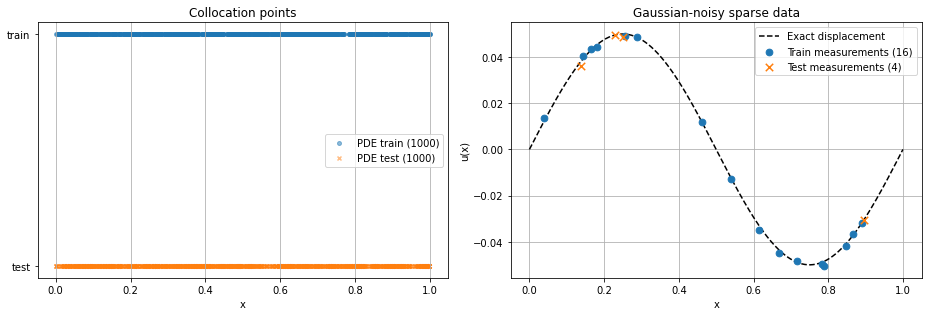

In [108]:
plot_points_and_data()


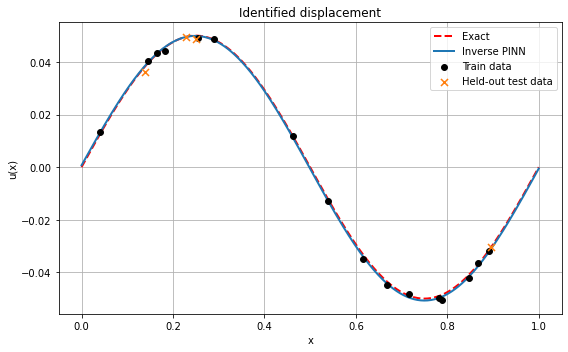

In [109]:
plot_solution()


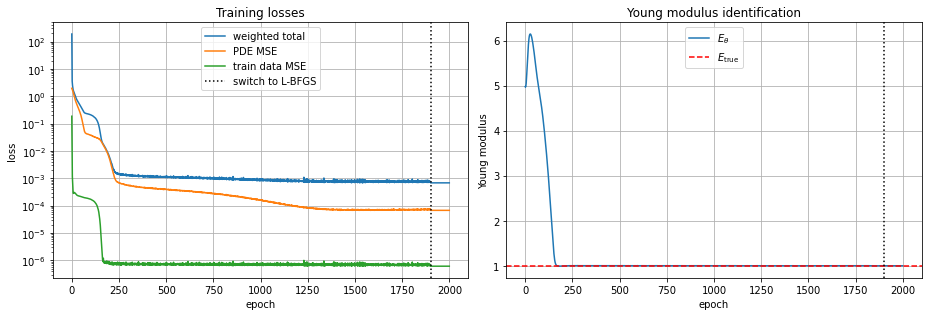

In [110]:
plot_loss_and_modulus()


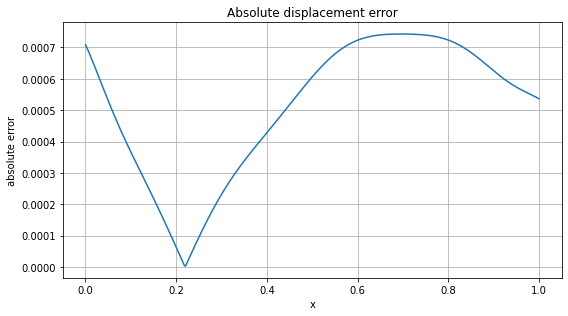

In [111]:
plot_absolute_error()
